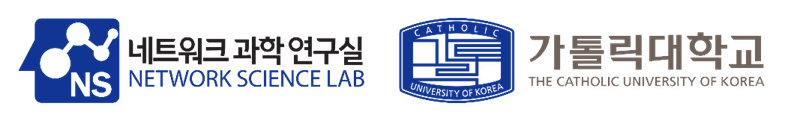

# 📊 Week 5: Over-smoothing, Over-squashing and Under-reaching

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Neural-Networks-Fall-2026/blob/main/W5/SampleCode_5.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

### Why can't a GNN simply "go deeper"?

A message-passing GNN with $L$ layers lets each node collect information from its **$L$-hop neighborhood**. That single fact creates three classic failure modes:

| Problem | What goes wrong | Root cause | Remedy in this notebook |
|:--|:--|:--|:--|
| **Over-smoothing** | After many layers, all node embeddings look the same | Repeated neighbor *averaging* | **JKNet** |
| **Over-squashing** | Information from far away arrives, but is squeezed to almost nothing | *Bottlenecks* in the graph topology | **SDRF**, **BORF** (graph rewiring) |
| **Under-reaching** | The needed information never arrives at all | Too few layers, $L <$ distance | **MixHop** |


<a id="setup"></a>
## 1. Setup

The installation cell is **opt-in**. On a fresh Colab runtime, set `INSTALL_DEPENDENCIES = True` and run it once. Everything else uses only PyTorch, PyG, NetworkX and SciPy.

In [1]:
INSTALL_DEPENDENCIES = False

if INSTALL_DEPENDENCIES:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-geometric"])

In [2]:
import random
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)  # Optional PyG extension notices.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import networkx as nx
from scipy.optimize import linprog
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, MixHopConv
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.utils import to_dense_adj

SEED = 42
DATA_ROOT = Path("data")  # Relative to the notebook kernel's working directory.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything()
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})
print(f"torch {torch.__version__} | device: {DEVICE}")

torch 2.11.0+cu126 | device: cuda


In [3]:
dataset = Planetoid(root=str(DATA_ROOT / "Cora"), name="Cora", transform=NormalizeFeatures())
cora = dataset[0].to(DEVICE)
print(cora)
print(f"{cora.num_nodes} papers · {cora.num_edges // 2} citation links · "
      f"{dataset.num_classes} topics · {int(cora.train_mask.sum())} training labels")

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
2708 papers · 5278 citation links · 7 topics · 140 training labels


<a id="smoothing"></a>
## 2. Over-smoothing: when every node starts to look the same

A GCN layer updates all nodes at once:

$$H^{(\ell+1)} = \sigma\!\left(\hat{A}\,H^{(\ell)}\,W^{(\ell)}\right),\qquad \hat{A} = \tilde{D}^{-1/2}(A+I)\tilde{D}^{-1/2}.$$

Multiplying by $\hat{A}$ replaces each node by a weighted **average** of itself and its neighbors — a low-pass filter. One or two averages remove noise; dozens of them wash out everything. As $k\to\infty$, $\hat{A}^k X$ converges to a matrix whose rows depend only on node degree, not on node features.

### 2.1. Watch it happen without any training

We strip the GCN down to pure propagation, $X^{(k)} = \hat{A}^k X$, and track the **Mean Average Distance (MAD)**: the average cosine distance between connected node pairs. MAD near $0$ means neighbors have become indistinguishable.

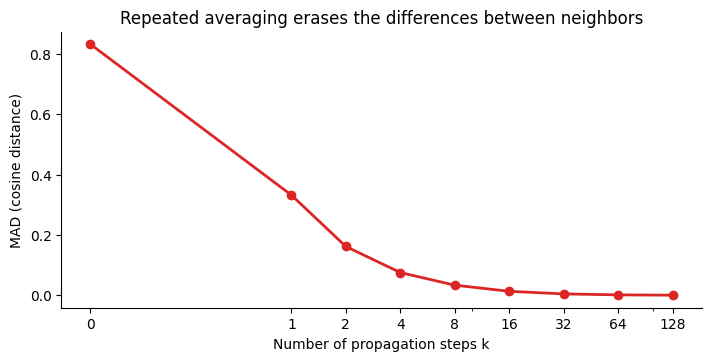

In [4]:
A_hat = to_dense_adj(cora.edge_index, max_num_nodes=cora.num_nodes)[0]
A_hat = A_hat + torch.eye(cora.num_nodes, device=DEVICE)
deg_inv_sqrt = A_hat.sum(1).pow(-0.5)
A_hat = deg_inv_sqrt[:, None] * A_hat * deg_inv_sqrt[None, :]


def mad(h, edge_index):
    # Mean cosine distance over the edges of the graph.
    h = F.normalize(h, dim=1)
    src, dst = edge_index
    return float((1 - (h[src] * h[dst]).sum(1)).mean())


steps = [0, 1, 2, 4, 8, 16, 32, 64, 128]
propagated, x_k = {}, cora.x.clone()
for k in range(max(steps) + 1):
    if k in steps:
        propagated[k] = x_k.clone()
    x_k = A_hat @ x_k
mad_curve = [mad(propagated[k], cora.edge_index) for k in steps]

fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
ax.plot(steps, mad_curve, "o-", color="#dc2626", linewidth=2)
ax.set_xscale("symlog", linthresh=1)
ax.set_xticks(steps)
ax.set_xticklabels(steps)
ax.set(title="Repeated averaging erases the differences between neighbors",
       xlabel="Number of propagation steps k", ylabel="MAD (cosine distance)")
plt.show()

The same effect is visible in feature space. Each panel projects $\hat{A}^kX$ to 2-D with PCA and colors nodes by their true topic. A few steps make the topics *easier* to separate (this is why a 2-layer GCN works so well). After many steps, the topics mix and the nodes pile onto a few thin curves: each connected component of Cora is converging to its own single point.

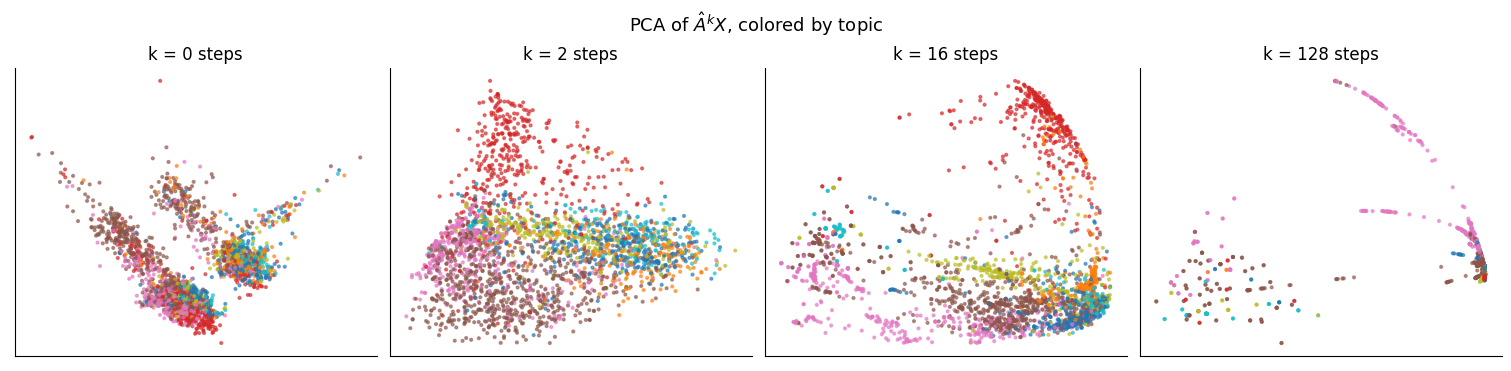

In [5]:
labels = cora.y.cpu().numpy()
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), constrained_layout=True)
for ax, k in zip(axes, [0, 2, 16, 128]):
    coords = PCA(n_components=2, random_state=SEED).fit_transform(
        F.normalize(propagated[k], dim=1).cpu().numpy())
    ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", s=4, alpha=0.6)
    ax.set(title=f"k = {k} steps", xticks=[], yticks=[])
fig.suptitle("PCA of $\\hat{A}^k X$, colored by topic", fontsize=13)
plt.show()

### 2.2. Deep GCNs lose accuracy

Now we actually train GCNs of increasing depth on Cora. Every model uses the same hidden size, optimizer and number of epochs; we keep the checkpoint with the best validation accuracy and report its test accuracy.

In [6]:
class DeepGCN(nn.Module):
    '''A plain stack of GCN layers. With jk="cat" it becomes a JKNet (Section 2.3).'''

    def __init__(self, in_dim, hidden, out_dim, num_layers, jk=None, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList(
            [GCNConv(in_dim if i == 0 else hidden, hidden) for i in range(num_layers)])
        self.jk, self.dropout = jk, dropout
        self.head = nn.Linear(hidden * num_layers if jk == "cat" else hidden, out_dim)

    def forward(self, x, edge_index):
        layer_outputs = []
        for conv in self.convs:
            x = F.dropout(x, self.dropout, self.training)
            x = F.relu(conv(x, edge_index))
            layer_outputs.append(x)
        if self.jk == "cat":                          # Jumping Knowledge: keep every layer
            x = torch.cat(layer_outputs, dim=1)
        return self.head(F.dropout(x, self.dropout, self.training))


def train_node_classifier(model, data, epochs=200, lr=0.01, weight_decay=5e-4):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val, best_test = 0.0, 0.0
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        F.cross_entropy(out[data.train_mask], data.y[data.train_mask]).backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            pred = model(data.x, data.edge_index).argmax(1)
        val = (pred[data.val_mask] == data.y[data.val_mask]).float().mean().item()
        test = (pred[data.test_mask] == data.y[data.test_mask]).float().mean().item()
        if val > best_val:
            best_val, best_test = val, test
    return best_test


DEPTHS = [2, 4, 8, 16, 32]
results = []
for depth in DEPTHS:
    seed_everything()
    acc = train_node_classifier(
        DeepGCN(dataset.num_features, 64, dataset.num_classes, depth), cora)
    results.append({"model": "GCN", "layers": depth, "test accuracy": acc})
    print(f"GCN   {depth:>2} layers → test accuracy {acc:.3f}")

GCN    2 layers → test accuracy 0.806


GCN    4 layers → test accuracy 0.727


GCN    8 layers → test accuracy 0.253


GCN   16 layers → test accuracy 0.312


GCN   32 layers → test accuracy 0.319


Accuracy peaks at 2 layers and collapses as the network gets deeper. Part of the drop is optimization difficulty, but the root cause is the one we just saw: the last layer only receives heavily smoothed features, so the classifier has little left to separate.

### 2.3. Remedy: Jumping Knowledge Networks (JKNet)

**Idea** (Xu et al., 2018): don't force the classifier to use only the last, smoothest layer. Let every layer "jump" directly to the output and combine them:

$$h_v^{\text{final}} = \operatorname{AGG}\left(h_v^{(1)}, h_v^{(2)}, \dots, h_v^{(L)}\right),\qquad \operatorname{AGG}\in\{\text{concat}, \max, \text{LSTM-attention}\}.$$

Early layers keep sharp local information, while later layers add wider context. The model *learns* how much of each range to use, and it can use a different mix for each node. We already built this into `DeepGCN` via `jk="cat"`.

JKNet  2 layers → test accuracy 0.800


JKNet  4 layers → test accuracy 0.774


JKNet  8 layers → test accuracy 0.777


JKNet 16 layers → test accuracy 0.800


JKNet 32 layers → test accuracy 0.802


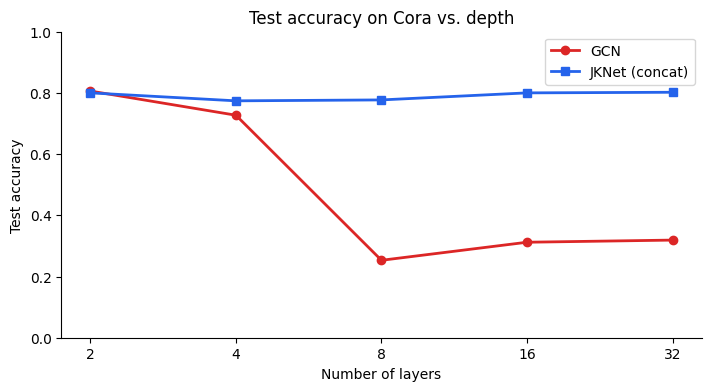

model,GCN,JKNet
layers,,
2,0.806,0.800
4,0.727,0.774
8,0.253,0.777
16,0.312,0.800
32,0.319,0.802


In [7]:
for depth in DEPTHS:
    seed_everything()
    acc = train_node_classifier(
        DeepGCN(dataset.num_features, 64, dataset.num_classes, depth, jk="cat"), cora)
    results.append({"model": "JKNet", "layers": depth, "test accuracy": acc})
    print(f"JKNet {depth:>2} layers → test accuracy {acc:.3f}")

depth_table = pd.DataFrame(results).pivot(index="layers", columns="model", values="test accuracy")
fig, ax = plt.subplots(figsize=(7, 3.8), constrained_layout=True)
ax.plot(depth_table.index, depth_table["GCN"], "o-", color="#dc2626", lw=2, label="GCN")
ax.plot(depth_table.index, depth_table["JKNet"], "s-", color="#2563eb", lw=2, label="JKNet (concat)")
ax.set_xscale("log", base=2)
ax.set_xticks(DEPTHS)
ax.set_xticklabels(DEPTHS)
ax.set(title="Test accuracy on Cora vs. depth", xlabel="Number of layers",
       ylabel="Test accuracy", ylim=(0, 1))
ax.legend()
plt.show()
depth_table.round(3)

<a id="squashing"></a>
## 3. Over-squashing: too much information through too narrow a pipe

The number of nodes within $L$ hops can grow exponentially with $L$, but every message must fit into one fixed-size vector. When many paths must pass through a few edges, a **bottleneck**, messages from far away are squashed.

Topping et al. (2022) showed that, across a bottleneck, a node barely reacts to changes in the features of a distant node, however well we train. They also showed *where* these bottlenecks sit: on edges with **negative curvature**.

### 3.1. A dumbbell graph and Balanced Forman curvature

Our test graph is a **dumbbell**: two dense communities (cliques of 8 nodes) joined by one bridge edge. For an edge $i\sim j$ with degrees $d_i, d_j$, the **Balanced Forman curvature** is

$$\operatorname{Ric}(i,j) = \frac{2}{d_i} + \frac{2}{d_j} - 2 + 2\frac{|\sharp_\Delta|}{\max(d_i,d_j)} + \frac{|\sharp_\Delta|}{\min(d_i,d_j)} + \frac{|\sharp_\square^i| + |\sharp_\square^j|}{\gamma_{\max}\,\max(d_i,d_j)},$$

where $\sharp_\Delta$ are the triangles on the edge, $\sharp_\square^i$ are neighbors of $i$ that start a 4-cycle through the edge, and $\gamma_{\max}$ is the largest number of such 4-cycles through a single neighbor. (Ric is set to $0$ when $\min(d_i,d_j)=1$.)

**Intuition:** triangles and 4-cycles give information *alternative routes* around an edge → positive curvature. An edge that is the *only* route between two dense regions has no such detours → strongly negative curvature.

In [8]:
def balanced_forman(G, i, j):
    '''Balanced Forman curvature of edge (i, j) — Topping et al., ICLR 2022.'''
    Ni, Nj = set(G[i]), set(G[j])
    di, dj = len(Ni), len(Nj)
    if min(di, dj) == 1:
        return 0.0
    triangles = len(Ni & Nj)

    def four_cycles(a, b, Na, Nb):
        # neighbors k of a (not adjacent to b) that reach b through some w not adjacent to a
        found = {}
        for k in Na - Nb - {b}:
            w = (set(G[k]) & Nb) - Na - {a}
            if w:
                found[k] = len(w)
        return found

    sq_i, sq_j = four_cycles(i, j, Ni, Nj), four_cycles(j, i, Nj, Ni)
    ric = 2 / di + 2 / dj - 2 + 2 * triangles / max(di, dj) + triangles / min(di, dj)
    gamma_max = max([*sq_i.values(), *sq_j.values(), 0])
    if gamma_max > 0:
        ric += (len(sq_i) + len(sq_j)) / (gamma_max * max(di, dj))
    return ric


def curvatures(G):
    return {e: balanced_forman(G, *e) for e in G.edges}


dumbbell = nx.barbell_graph(8, 0)        # nodes 0–7 = left clique, 8–15 = right clique
LEFT, RIGHT = list(range(8)), list(range(8, 16))
POS = nx.spring_layout(dumbbell, seed=3)
curv = curvatures(dumbbell)
print("Distinct curvature values:", sorted({round(c, 3) for c in curv.values()}))
print("Most negative edge:", min(curv, key=curv.get), f"→ {min(curv.values()):.2f}")

Distinct curvature values: [-1.5, 0.893, 1.143]
Most negative edge: (7, 8) → -1.50


Let's draw every edge colored by its curvature: <span style="color:#dc2626">**red = positive**</span>, <span style="color:#2563eb">**blue = negative**</span>. The blue edge marks the bottleneck.

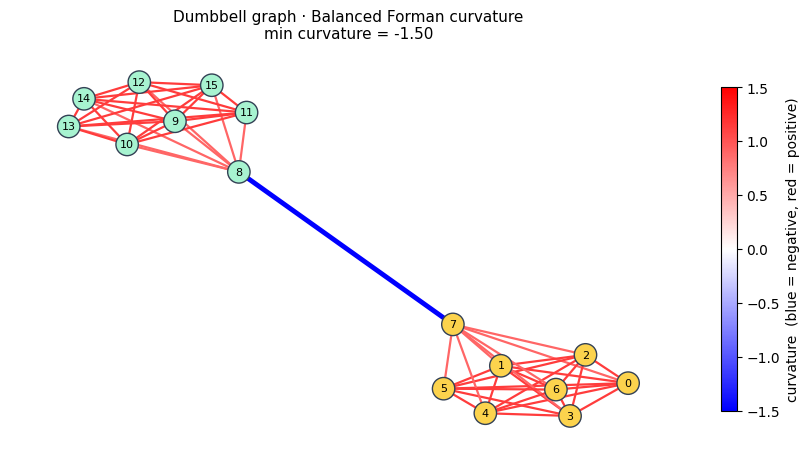

In [9]:
CURV_NORM = TwoSlopeNorm(vmin=-1.5, vcenter=0.0, vmax=1.5)
CURV_CMAP = plt.cm.bwr                      # blue (negative) → white (0) → red (positive)


def draw_curvature(G, ax, title):
    curv = curvatures(G)
    edges = list(G.edges)
    values = [curv[e] for e in edges]
    node_colors = ["#fcd34d" if n in LEFT else "#a7f3d0" for n in G.nodes]
    widths = [3.5 if v < 0 else 1.6 for v in values]
    nx.draw_networkx_edges(G, POS, edgelist=edges, edge_color=values, edge_cmap=CURV_CMAP,
                           edge_vmin=CURV_NORM.vmin, edge_vmax=CURV_NORM.vmax, width=widths, ax=ax)
    nx.draw_networkx_nodes(G, POS, node_color=node_colors, edgecolors="#334155", node_size=260, ax=ax)
    nx.draw_networkx_labels(G, POS, font_size=8, ax=ax)
    ax.set_title(f"{title}\nmin curvature = {min(values):.2f}", fontsize=11)
    ax.axis("off")


fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
draw_curvature(dumbbell, ax, "Dumbbell graph · Balanced Forman curvature")
fig.colorbar(plt.cm.ScalarMappable(norm=CURV_NORM, cmap=CURV_CMAP), ax=ax,
             label="curvature  (blue = negative, red = positive)", shrink=0.8)
plt.show()

### 3.2. Remedy: rewire the graph with curvature

If negatively curved edges cause the squash, we can **edit the graph** before training: add edges that give the bottleneck some detours, and remove edges in over-connected regions so the graph does not become too dense. Both methods below are *preprocessing*: any GNN can then run on the rewired graph.

**SDRF - Stochastic Discrete Ricci Flow** (Topping et al., 2022), using Balanced Forman curvature:
1. Find the edge $(i,j)$ with the **most negative** curvature.
2. For every candidate edge $(k,l)$ with $k\in\mathcal{N}(i)\cup\{i\}$, $l\in\mathcal{N}(j)\cup\{j\}$, compute how much adding it would raise $\operatorname{Ric}(i,j)$.
3. Sample one candidate with probability $\propto \exp(\tau\cdot\text{improvement})$ and add it.
4. If the most **positive** edge has curvature above $C^+$, remove it.
5. Repeat for a fixed number of iterations, one edge at a time.

In [10]:
def sdrf(G, iterations=8, tau=5.0, c_plus=1.0, seed=SEED):
    rng = np.random.default_rng(seed)
    G, added = G.copy(), []
    for _ in range(iterations):
        curv = curvatures(G)
        i, j = min(curv, key=curv.get)                      # 1. worst bottleneck
        candidates, gains = [], []
        for k in [i, *G[i]]:                                # 2. try every detour edge
            for l in [j, *G[j]]:
                if k != l and not G.has_edge(k, l):
                    G.add_edge(k, l)
                    gains.append(balanced_forman(G, i, j) - curv[(i, j)])
                    G.remove_edge(k, l)
                    candidates.append((k, l))
        if candidates:                                      # 3. soft-max sampling
            g = np.array(gains)
            p = np.exp(tau * (g - g.max()))
            k, l = candidates[rng.choice(len(candidates), p=p / p.sum())]
            G.add_edge(k, l)
            added.append((k, l))
        curv = curvatures(G)                                # 4. prune the most positive edge
        e = max(curv, key=curv.get)
        if curv[e] > c_plus:
            G.remove_edge(*e)
    return G, added


dumbbell_sdrf, sdrf_added = sdrf(dumbbell)
print("SDRF added:", sdrf_added)
print(f"Edges: {dumbbell.number_of_edges()} → {dumbbell_sdrf.number_of_edges()}")

SDRF added: [(5, 8), (2, 8), (6, 10), (4, 10), (6, 11), (7, 14), (4, 8), (4, 14)]
Edges: 57 → 59


**BORF - Batch Ollivier-Ricci Flow** (Nguyen et al., 2023) uses **Ollivier-Ricci curvature** instead. For an edge $(u,v)$, spread one unit of mass uniformly over the neighbors of $u$ (distribution $\mu_u$) and of $v$ ($\mu_v$). Then

$$\kappa(u,v) = 1 - W_1(\mu_u, \mu_v),$$

where $W_1$ is the optimal-transport cost of moving $\mu_u$ onto $\mu_v$ along shortest paths. If the neighborhoods overlap, the transport is cheap → positive; if they only meet through $(u,v)$, it is expensive → negative. We solve the small transport problem with `scipy.optimize.linprog`.

BORF works in **batches**, which makes it much faster than SDRF on real graphs:
1. Compute the curvature of all edges once.
2. For each of the $h$ most negative edges, add an edge between the neighbor pair $(p,q)$ that carries the **most mass** in the optimal transport plan - the route that is used most.
3. Remove the $k$ most positive edges.
4. Repeat for a few batches.

In [11]:
def ollivier_ricci(G, u, v, dist):
    '''Ollivier-Ricci curvature of (u, v) and its optimal transport plan.'''
    Nu, Nv = list(G[u]), list(G[v])
    mu, mv = np.full(len(Nu), 1 / len(Nu)), np.full(len(Nv), 1 / len(Nv))
    cost = np.array([[dist[a][b] for b in Nv] for a in Nu], dtype=float)
    n, m = cost.shape
    A_eq = np.vstack([np.kron(np.eye(n), np.ones(m)),       # every source sends its mass
                      np.kron(np.ones(n), np.eye(m))])       # every target receives its mass
    res = linprog(cost.ravel(), A_eq=A_eq, b_eq=np.concatenate([mu, mv]),
                  bounds=(0, None), method="highs")
    return 1 - res.fun / dist[u][v], Nu, Nv, res.x.reshape(n, m)


def borf(G, batches=3, h=2, k=2):
    G, added = G.copy(), []
    for _ in range(batches):
        dist = dict(nx.all_pairs_shortest_path_length(G))
        orc = {e: ollivier_ricci(G, *e, dist)[0] for e in G.edges}   # 1. one pass over all edges
        order = sorted(orc, key=orc.get)
        for u, v in order[:h]:                                        # 2. fix the h worst edges
            _, Nu, Nv, plan = ollivier_ricci(G, u, v, dist)
            pairs = [(plan[a, b], p, q) for a, p in enumerate(Nu) for b, q in enumerate(Nv)
                     if p != q and not G.has_edge(p, q)]
            if pairs:
                _, p, q = max(pairs)
                G.add_edge(p, q)
                added.append((p, q))
        for e in order[-k:]:                                          # 3. prune the k most positive
            if G.has_edge(*e):
                G.remove_edge(*e)
    return G, added


dist = dict(nx.all_pairs_shortest_path_length(dumbbell))
bridge_orc = ollivier_ricci(dumbbell, 7, 8, dist)[0]
print(f"Ollivier-Ricci curvature of the bridge (7, 8): {bridge_orc:.2f}")
dumbbell_borf, borf_added = borf(dumbbell)
print("BORF added:", borf_added)
print(f"Edges: {dumbbell.number_of_edges()} → {dumbbell_borf.number_of_edges()}")

Ollivier-Ricci curvature of the bridge (7, 8): -1.50


BORF added: [(6, 15), (6, 8), (6, 10), (5, 12), (7, 9), (5, 14)]
Edges: 57 → 57


Both methods agree that the bridge is the bottleneck. Let's compare the three graphs side by side, still colored by Balanced Forman curvature.

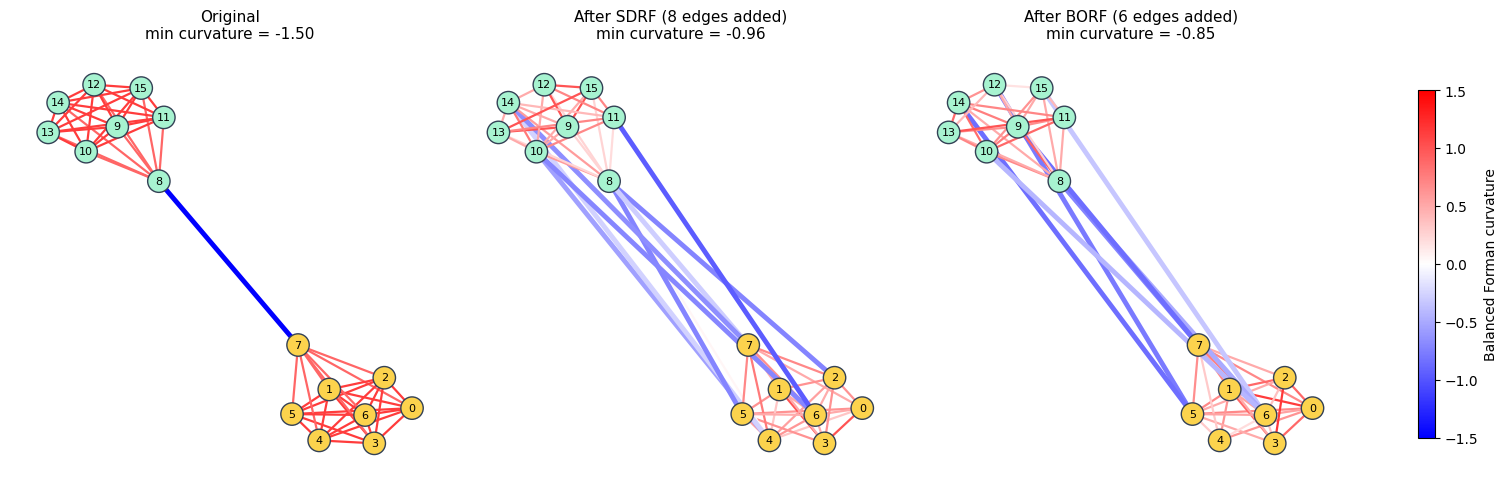

In [12]:
graphs = {"Original": (dumbbell, ()),
          "After SDRF": (dumbbell_sdrf, sdrf_added),
          "After BORF": (dumbbell_borf, borf_added)}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
for ax, (name, (G, added)) in zip(axes, graphs.items()):
    draw_curvature(G, ax, f"{name} ({len(added)} edges added)" if added else name)
fig.colorbar(plt.cm.ScalarMappable(norm=CURV_NORM, cmap=CURV_CMAP), ax=axes,
             label="Balanced Forman curvature", shrink=0.8)
plt.show()

<a id="reaching"></a>
## 4. Under-reaching: the information never arrives

Over-squashing is about information that arrives *too weakly*. Under-reaching is simpler and harsher: an $L$-layer GNN has a receptive field of exactly $L$ hops. If the answer depends on a node that is farther away, **no amount of training can help**.

### 4.1. A long-range task on chains

Each graph is a chain of 6 nodes. The **source** node at one end carries a random class (0 or 1) as a one-hot feature. The **target** node at the other end, 5 hops away, must predict that class. Every other node has only zero features. A model that cannot see the source is left with a coin flip.

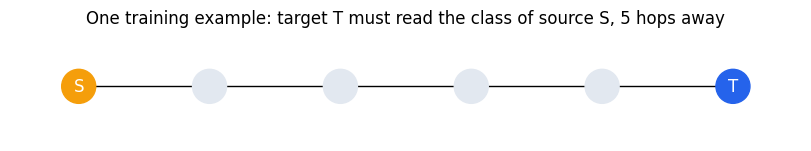

In [13]:
CHAIN_LENGTH = 6                      # target is CHAIN_LENGTH - 1 = 5 hops from the source


def make_chain(label):
    x = torch.zeros(CHAIN_LENGTH, 3)
    x[0, label] = 1.0                  # source: one-hot class
    x[-1, 2] = 1.0                     # target: "I am the target" flag
    edges = torch.tensor([[i, i + 1] for i in range(CHAIN_LENGTH - 1)]).t()
    edge_index = torch.cat([edges, edges.flip(0)], dim=1)
    target_mask = torch.zeros(CHAIN_LENGTH, dtype=torch.bool)
    target_mask[-1] = True
    return Data(x=x, edge_index=edge_index, y=torch.full((CHAIN_LENGTH,), label), target_mask=target_mask)


seed_everything()
chain_labels = torch.randint(0, 2, (600,)).tolist()
chain_train = Batch.from_data_list([make_chain(c) for c in chain_labels[:400]]).to(DEVICE)
chain_test = Batch.from_data_list([make_chain(c) for c in chain_labels[400:]]).to(DEVICE)

chain = nx.path_graph(CHAIN_LENGTH)
fig, ax = plt.subplots(figsize=(8, 1.4), constrained_layout=True)
colors = ["#f59e0b"] + ["#e2e8f0"] * (CHAIN_LENGTH - 2) + ["#2563eb"]
nx.draw_networkx(chain, {i: (i, 0) for i in chain}, node_color=colors, node_size=600,
                 labels={0: "S", CHAIN_LENGTH - 1: "T"}, font_color="white", ax=ax)
ax.set_title(f"One training example: target T must read the class of source S, {CHAIN_LENGTH - 1} hops away")
ax.axis("off")
plt.show()

In [14]:
class ChainGCN(nn.Module):
    def __init__(self, num_layers, hidden=32):
        super().__init__()
        self.convs = nn.ModuleList([GCNConv(3 if i == 0 else hidden, hidden) for i in range(num_layers)])
        self.head = nn.Linear(hidden, 2)

    def forward(self, x, edge_index):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
        return self.head(x)


def train_chain_model(model, epochs=300, lr=0.01):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    tr = chain_train
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(tr.x, tr.edge_index)
        F.cross_entropy(out[tr.target_mask], tr.y[tr.target_mask]).backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        pred = model(chain_test.x, chain_test.edge_index).argmax(1)
    m = chain_test.target_mask
    return (pred[m] == chain_test.y[m]).float().mean().item()


reach_results = []
for L in range(1, CHAIN_LENGTH + 1):
    seed_everything()
    acc = train_chain_model(ChainGCN(L))
    reach_results.append({"model": f"GCN · {L} layer{'s' if L > 1 else ''}", "hops seen": L, "accuracy": acc})
    print(f"GCN with {L} layer(s) (sees {L} hops) → target accuracy {acc:.2f}")

GCN with 1 layer(s) (sees 1 hops) → target accuracy 0.56


GCN with 2 layer(s) (sees 2 hops) → target accuracy 0.56


GCN with 3 layer(s) (sees 3 hops) → target accuracy 0.56


GCN with 4 layer(s) (sees 4 hops) → target accuracy 0.56


GCN with 5 layer(s) (sees 5 hops) → target accuracy 1.00


GCN with 6 layer(s) (sees 6 hops) → target accuracy 1.00


Accuracy sits at chance level (≈ 0.5; the model can only guess the most common class) until the model has at least 5 layers - exactly the distance to the source. The obvious fix is "just add layers", but Section 2 showed that stacking layers invites over-smoothing, and Section 3 showed that long paths suffer from over-squashing. Can we reach farther *without* stacking so many layers?

### 4.2. Remedy: MixHop

**Idea** (Abu-El-Haija et al., 2019): within **one** layer, aggregate from several powers of the adjacency matrix and concatenate the results:

$$H^{(\ell+1)} = \Big\Vert_{p\in P}\; \sigma\!\left(\hat{A}^{\,p}\,H^{(\ell)}\,W_p^{(\ell)}\right),\qquad P = \{0, 1, 2, 3\}.$$

A single MixHop layer therefore sees 3 hops, so two layers cover 6 hops. Because the power-0 and power-1 channels are kept separately, near and far information is **not** blended into one average; the next layer can weigh them differently (the same spirit as JKNet). PyG provides this as `MixHopConv`.

MixHop with 2 layers, powers 0–3 (sees 6 hops) → target accuracy 1.00


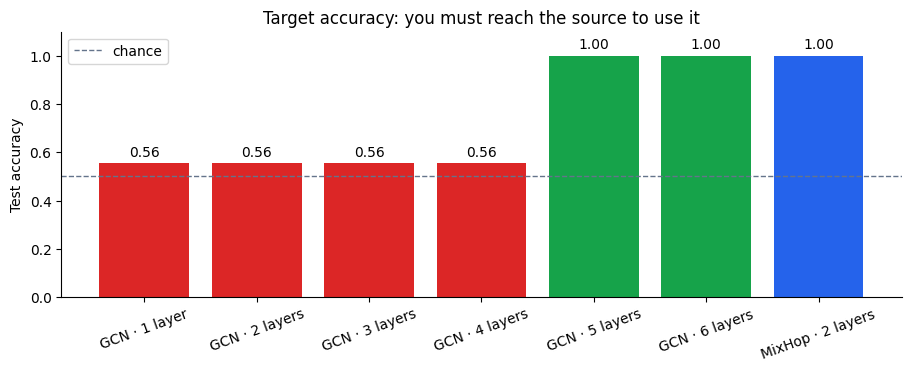

In [15]:
class ChainMixHop(nn.Module):
    def __init__(self, num_layers=2, hidden=16, powers=(0, 1, 2, 3)):
        super().__init__()
        width = hidden * len(powers)            # MixHopConv concatenates one block per power
        self.convs = nn.ModuleList([MixHopConv(3 if i == 0 else width, hidden, powers=list(powers))
                                    for i in range(num_layers)])
        self.head = nn.Linear(width, 2)

    def forward(self, x, edge_index):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
        return self.head(x)


seed_everything()
acc = train_chain_model(ChainMixHop(num_layers=2))
reach_results.append({"model": "MixHop · 2 layers", "hops seen": 6, "accuracy": acc})
print(f"MixHop with 2 layers, powers 0–3 (sees 6 hops) → target accuracy {acc:.2f}")

reach_table = pd.DataFrame(reach_results)
fig, ax = plt.subplots(figsize=(9, 3.6), constrained_layout=True)
bar_colors = ["#dc2626" if h < CHAIN_LENGTH - 1 else "#16a34a" for h in reach_table["hops seen"][:-1]] + ["#2563eb"]
bars = ax.bar(reach_table["model"], reach_table["accuracy"], color=bar_colors)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.axhline(0.5, color="#64748b", ls="--", lw=1, label="chance")
ax.set(title="Target accuracy: you must reach the source to use it", ylabel="Test accuracy", ylim=(0, 1.1))
ax.tick_params(axis="x", rotation=20)
ax.legend(loc="upper left")
plt.show()


### Further reading
- Li, Han & Wu. *Deeper Insights into Graph Convolutional Networks for Semi-Supervised Learning.* AAAI 2018 (over-smoothing).
- Xu et al. *Representation Learning on Graphs with Jumping Knowledge Networks.* ICML 2018 (JKNet).
- Abu-El-Haija et al. *MixHop: Higher-Order Graph Convolutional Architectures via Sparsified Neighborhood Mixing.* ICML 2019.
- Alon & Yahav. *On the Bottleneck of Graph Neural Networks and its Practical Implications.* ICLR 2021 (over-squashing).
- Topping et al. *Understanding Over-squashing and Bottlenecks on Graphs via Curvature.* ICLR 2022 (Balanced Forman curvature, SDRF).
- Nguyen et al. *Revisiting Over-smoothing and Over-squashing Using Ollivier-Ricci Curvature.* ICML 2023 (BORF).